corresponding to archive-46

In [40]:
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math

ub:ub7ma, mean:0.9652188800235331
ub:ub11, mean:0.9299018118989292
ub:ub11m, mean:0.9665976412592359
ub:ub7u, mean:0.9299018118989292
ub:ub7mu, mean:0.9665976412592356
count:1/6 caltech_100.pdf completed.


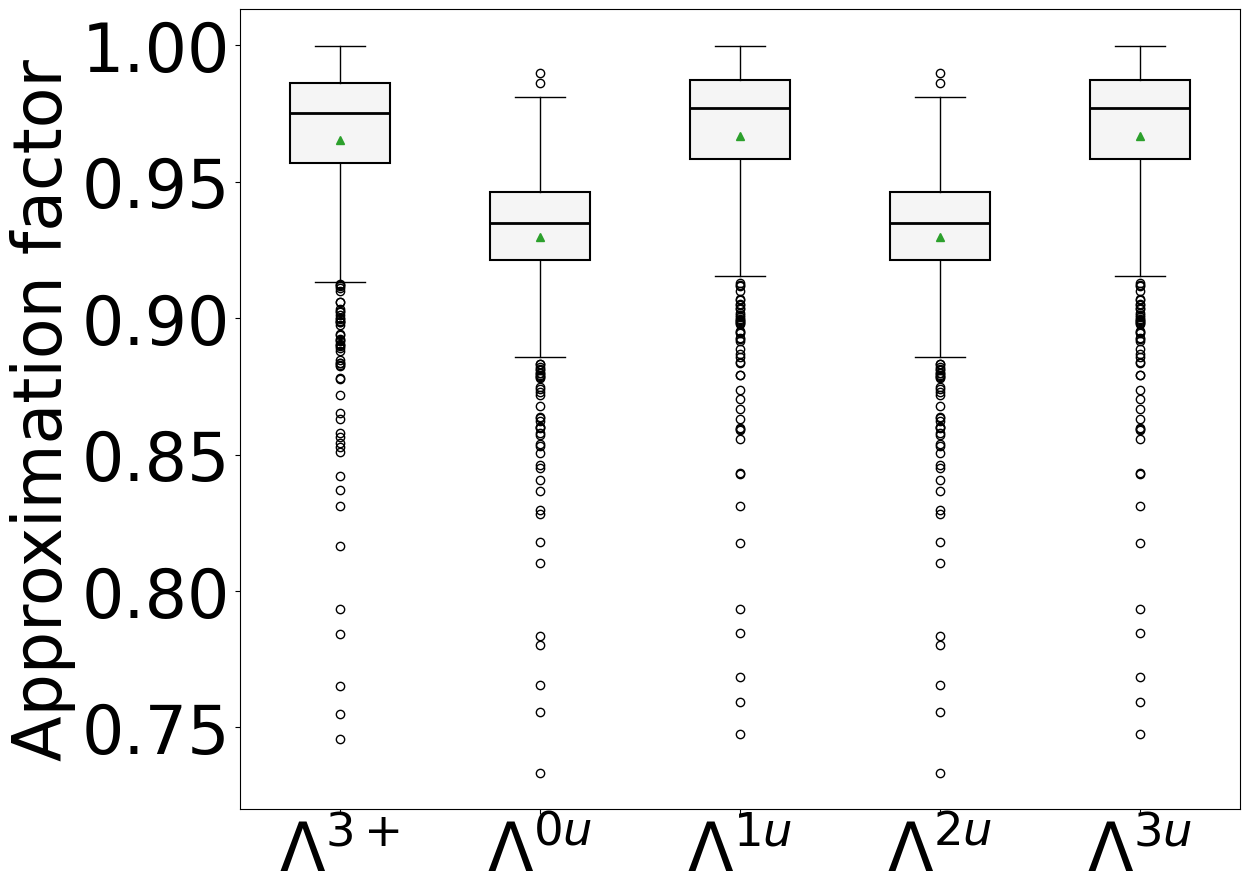

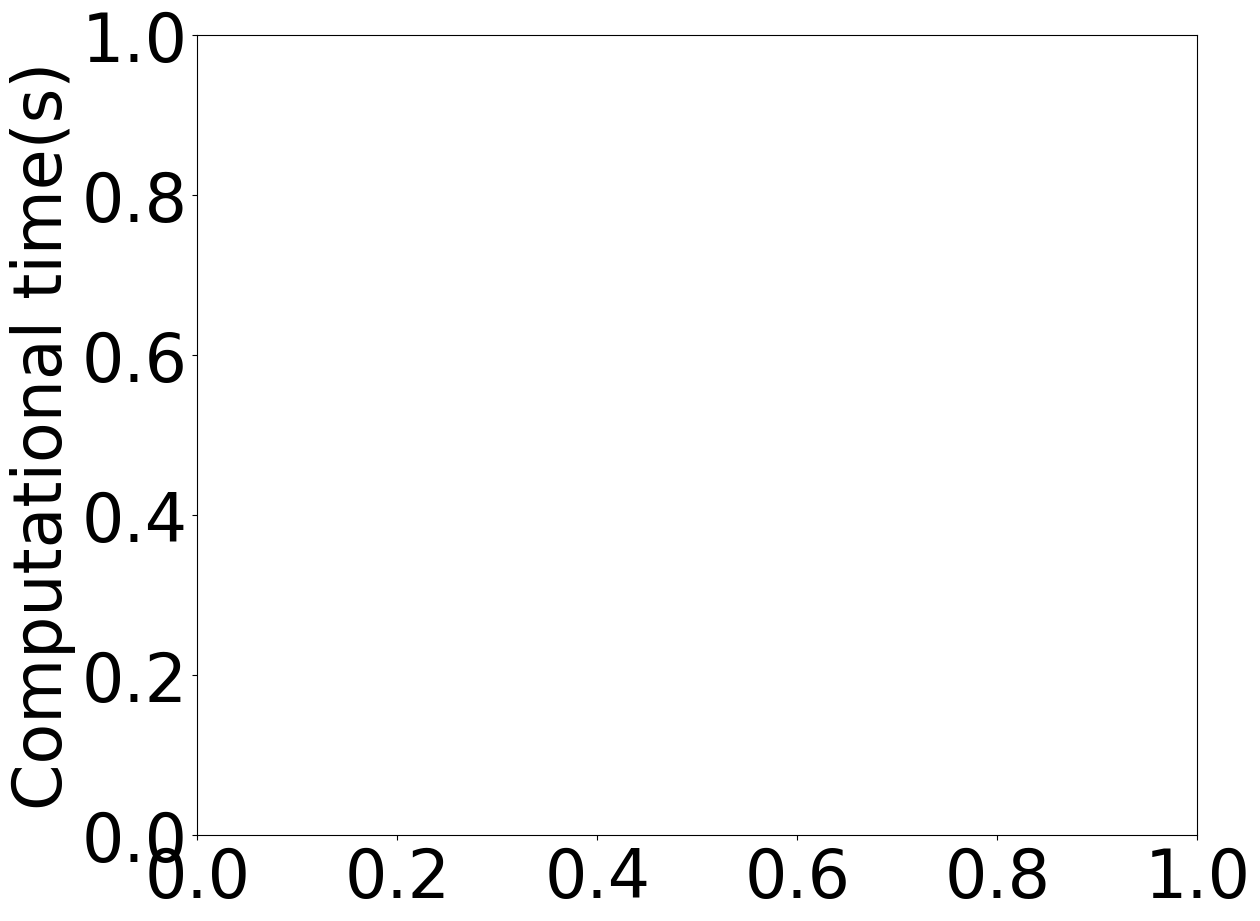

In [50]:
t = False

def load_12_series(upper_bound: str, task_name: str, source_dir: str):
    """
    kv_data has the following keys: 
    - 'S'
    - 'f(S)'
    - 'c(S)'
    - 'Lambda'
    - 'AF'
    """
    task_dict = {
        "facebook": "FacebookGraphCoverage",
        "youtube" : "YoutubeCoverage",
        "caltech": "CalTechMaximization",
        "adult": "AdultIncomeFeatureSelection"
    }

    res = []
    # print(f"r:{source_dir}")
    for name in os.listdir(source_dir):
        # print(f"name:{name}")
        if not os.path.isdir(os.path.join(source_dir, name)):
            algo, up, task, budget = name.strip()[:-5].split('-')
            # algo, up, task, b = name.strip()[:-5].split('-')
            # print(f"u:{upper_bound}, t:{task_name}, up:{up}, task:{task}")
            
            if up == upper_bound and task_dict[task_name] == task and algo == 'modified_greedy':
                # print(name)
                file_path = os.path.join(source_dir, name)
                with open(file_path, "rb") as rd:
                    kv_data = pickle.load(rd)
                # print(kv_data)
                if t:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['Time']) )
                else:
                    res.append( (eval(budget), kv_data['f(S)'], kv_data['Lambda'], kv_data['AF']) )
    res = sorted(res, key=lambda x: x[0])
    # print(res)
    X, Y, Z, W = list(zip(*res))   # change it to two columns
    return X, Y, Z, W

task_list = ['caltech']

ub_list = [
    'ub7ma', 'ub11', 'ub11m', 'ub7u', 'ub7mu'
]

ub_title_dict = {
    'ub1r':r'$\Lambda^{0r}$',
    'ub1mr':r'$\Lambda^{1r}$',
    'ub7r':r'$\Lambda^{2r}$',
    'ub7':r'$\Lambda^{2+}$',
    'ub7ma':r'$\Lambda^{3+}$',
    'ub11':r'$\Lambda^{0u}$',
    'ub11m':r'$\Lambda^{1u}$',
    'ub7u':r'$\Lambda^{2u}$',
    'ub7mu':r'$\Lambda^{3u}$',
    'ub7mr':r'$\Lambda^{3r}$',
    'ub1ru':r'$\Lambda^{0r unified}$'
}

ub_title_list = [ub_title_dict[ub] for ub in ub_list]

archive_dir = "../result/archive-52"

result_dir = "./result_unified_23_20"

n = 100
worst_case = math.log(n, math.e)
fs = 48

u_data_list = []
for ub in ub_list:
    u_data_list.append([])

seed_range = range(0, 20)
b_range = range(6, 41)

b_data_list = []
for ub in ub_list:
    temp = []
    for v in b_range:
        temp.append([])
    b_data_list.append(temp)
bti_dict = {}
for i in range(0, len(b_range)):
    b = float(b_range[i])
    bti_dict[b] = i

ub_to_draw_list = [0, 1]

count = 0
total_count = len(task_list) + len(ub_list) * len(task_list)

for task in task_list:
    for seed in seed_range:
        for ub_idx in range(0, len(ub_list)):
            # print(f"seed:{seed}")
            ub = ub_list[ub_idx]
            source_dir = os.path.join(archive_dir, f"{task}", f"{n}", f"{seed}")
            # print(f"seed:{seed}")
            X, Y, Z, W = load_12_series(upper_bound=ub, task_name=task, source_dir=source_dir)

            ub2uv, ub3uv, v2vv, v3vv, v2sv, v3sv = 0, 0, 0, 0, 0, 0
            s2s, s3s = None, None
            for x_idx in range(0, len(X)):
                b = X[x_idx]
                if b in b_range:
                    b_list_idx = bti_dict[b]
                    b_data_list[ub_idx][b_list_idx].append(W[x_idx])    
                    u_data_list[ub_idx].append(W[x_idx])
                    if ub_idx == 3:
                        ub2uv = W[x_idx]
                        v2vv = Z[x_idx]
                        v2sv = Y[x_idx]
                        s2s = source_dir
                    elif ub_idx == 4:
                        ub3uv = W[x_idx]
                        v3vv = Z[x_idx]
                        v3sv = Y[x_idx]
                        s3s = source_dir
                        if ub3uv < ub2uv:
                            print(f"seed:{seed}, b:{b}, u2uv:{ub2uv}, ub3uv:{ub3uv},value:{v2vv}, value:{v3vv}, sv:{v2sv}, svv:{v3sv}")
    # first plot
    data = u_data_list

    plt.rcParams["font.size"] = fs
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_axes([0,0,1,1])
    if t:
        ax.set_ylabel("Computational time(s)")
    else:
        ax.set_ylabel("Approximation factor")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)

    for ub_idx in range(0, len(ub_list)):
        ub = ub_list[ub_idx]
        print(f"ub:{ub}, mean:{np.mean(data[ub_idx])}")

    bp = ax.boxplot(data, patch_artist=True, showfliers=True, tick_labels=ub_title_list, showmeans=True, boxprops=box_props, medianprops=median_props)
    # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 
    
    ax.plot()

    plt.xticks(fontsize=fs) 

    for median in bp["medians"]:
        median.set_color("black")

    for box in bp["boxes"]:
        box.set_facecolor("whitesmoke")


    suffix=""
    if t:
        suffix="_T"
    else:
        suffix=""

    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.pdf"), format='pdf', bbox_inches='tight')
    plt.savefig(os.path.join(result_dir, f"{task}_{n}{suffix}.jpg"), format='jpg', bbox_inches='tight')
    count = count + 1
    print(f"count:{count}/{total_count} {task}_{n}{suffix}.pdf completed.")

    # second plot

    fig = plt.figure(figsize=(10, 8))

    ax = fig.add_axes([0,0,1,1])
    # ax.set_ylabel("Approximation factor")
    ax.set_ylabel("Computational time(s)")

    box_props = dict(linewidth=1.5, color="black")
    median_props = dict(linewidth=2)
    mean_props = {"marker":"^","markerfacecolor":"darkgreen", "markeredgecolor":"darkgreen"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    flier_props = {"marker":"o","markerfacecolor":"darkgreen", "markeredgecolor":"black"}
    whisker_props = {"color":"black"}

    color_list = ["whitesmoke","wheat", 'cornsilk']

    whisker_color_list = ["dimgray","orange",'cornsilk']
    cc = 0

    # for i in ub_to_draw_list:
    #     data = b_data_list[i]
    #     ub = ub_list[i]

    #     flier_props["markerfacecolor"] = color_list[cc]
    #     whisker_props["color"] = whisker_color_list[cc]

    #     xtick_labels = []
    #     for b in b_range:
    #         if int(b) % 2 == 1:
    #             xtick_labels.append(b)
    #         else:
    #             xtick_labels.append(" ")

    #     bp = ax.boxplot(data,label=ub_title_dict[ub], patch_artist=True, tick_labels=xtick_labels, showmeans=True, boxprops=box_props, medianprops=median_props
    #                     , meanprops=mean_props, flierprops=flier_props, whiskerprops=whisker_props, capprops=whisker_props)
    #     # plt.axhline(y = worst_case, color = 'r', linestyle = '-') 

    #     for median in bp["medians"]:
    #         median.set_color("black")
    #     for box in bp["boxes"]:
    #         box.set_facecolor(color_list[cc])

    #     cc = cc + 1

    #     plt.legend()

    #     plt.savefig(os.path.join(result_dir, f"{task}_{n}_v{suffix}.jpg"), format='jpg', bbox_inches='tight')
    #     count = count + 1
    #     print(f"count:{count}/{total_count} {task}_v.jpg completed.")
    

youtube: 
ub:ub7ma, mean:0.9582867090598242
ub:ub11, mean:0.9611532377303219
ub:ub11m, mean:0.9611532377303219
ub:ub7u, mean:0.9611532377303217
ub:ub7mu, mean:0.9611532377303219

ub:ub7ma, mean:9.243623713084629
ub:ub11, mean:4.990155854906354
ub:ub11m, mean:8.678127495561327
ub:ub7u, mean:92.12287601402828
ub:ub7mu, mean:88.15307073865618
facebook:
ub:ub7ma, mean:0.906413321843172
ub:ub11, mean:0.9369806875200489
ub:ub11m, mean:0.9369806875200489
ub:ub7u, mean:0.9369810788249513
ub:ub7mu, mean:0.9369810788249513

ub:ub7ma, mean:41.43556034156254
ub:ub11, mean:22.48161468744278
ub:ub11m, mean:32.53470688956124
ub:ub7u, mean:224.22911675146648
ub:ub7mu, mean:230.15263302292144
adult:
ub:ub7ma, mean:0.9464274722566821
ub:ub11, mean:0.9279227659135875
ub:ub11m, mean:0.9279227659135875
ub:ub7u, mean:0.9472846774763409
ub:ub7mu, mean:0.9472846774763409

ub:ub7ma, mean:28.909229665143148
ub:ub11, mean:7.363404408182417
ub:ub11m, mean:10.999628932816641
ub:ub7u, mean:16.257781765801568
ub:ub7mu, mean:19.5762131857872
caltech:
ub:ub7ma, mean:0.9652188800235331
ub:ub11, mean:0.9299018118989292
ub:ub11m, mean:0.9665976412592359
ub:ub7u, mean:0.9299018118989292
ub:ub7mu, mean:0.9665976412592356

ub:ub7ma, mean:7.701127650397164
ub:ub11, mean:5.658287454673222
ub:ub11m, mean:6.240117999485561
ub:ub7u, mean:7.533744722775051
ub:ub7mu, mean:8.605766882215228